# Lecture: Object Detection and Image Segmentation

Instructor: Amna Mazen

## Object Detection

### What is Object Detection?

- In an image classification task, the network assigns a label (or class) to each input image.




Reference: https://www.analyticsvidhya.com/blog/2019/04/introduction-image-segmentation-techniques-python/


Let’s understand the image segmentation algorithm using a simple example. Consider the below image:

<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/dog.jpeg" alt="Image" />
</center>

There’s only **one** object here – a dog. We can build a straightforward cat-dog classifier model and predict that there’s a dog in the given image. This is called **Classification**.


But what if we have **a cat and a dog in a single image**?

<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/objectdetection.png" alt="Image" />
</center>

**Object Localization**

Ytrain=[Pc
 Bx
 By
 BW
 BH
 C1
 C2
 ] %Center of Bounding Box

 or

Ytrain=[Pc
 Bx
 By
 BW
 BH
 C1
 C2
 ] %Top Left Corner of Bounding Box

 or

Ytrain=[Pc
 Bx1
 By1
 Bx2
 By2
 C1
 C2
 ]

 In general it is pixel wise or normalized BB. Innormalized BB, given the resolution of the image you can convert it into pixel wise

That’s where image localization comes into the picture (no pun intended!). It helps us identify a single object’s location in the given image. We rely on **object detection (OD)** if we have multiple objects present. We can predict the location and class for each object using OD.

### Object Detection algorithms:

1. **Single-Stage Detectors (Real-time Focus):**
Detect objects directly without region proposals.
- **YOLO (You Only Look Once):** Very fast, grid-based detection
- **SSD (Single Shot Detector):** Multi-scale feature maps for detection
- **RetinaNet:** Single-stage with Focal Loss to handle class imbalance


2. **Two-Stage Detectors (Region Proposal Based):**
These generate region proposals first, then classify/detect objects.
- **R-CNN (Region-CNN):** Extracts region proposals → CNN feature extraction → classification
- **Fast R-CNN:** Faster than R-CNN by sharing convolutional features
- **Faster R-CNN:** Introduced Region Proposal Network (RPN) for faster region proposal generation
- **Mask R-CNN:** Extends Faster R-CNN to also perform pixel-wise instance segmentation

3. **Transformer-based Detectors (Recent Trends):**
These use attention mechanisms for detection.
- **DETR (Detection Transformer):** 	End-to-end object detection using transformers
- **Deformable DETR**: Improves DETR speed and accuracy
- **YOLOS**: Transformer adaptation of YOLO

**What is YOLO exactly?**

YOLO (You Only Look Once) is a method / way to do object detection. It is the algorithm /strategy behind how the code is going to detect objects in the image.

Earlier detection frameworks, looked at different parts of the image multiple times at different scales and repurposed image classification technique to detect objects. This approach is slow and inefficient.

YOLO takes entirely different approach. It looks at the entire image only once and goes through the network once and detects objects. Hence the name. It is very fast. That’s the reason it has got so popular.

Video about Yolo: https://www.youtube.com/watch?v=ag3DLKsl2vk


### Step-by-Step Tutorial: YOLOv8 Object Detection

Step 1: Install YOLOv8 (Ultralytics Library)

This will install YOLOv8 and its dependencies.

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

Step 2: Import YOLOv8 Library

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Step 4: Load Pre-trained YOLOv8 Model

You can use different models depending on speed vs accuracy:

- yolov8n.pt → nano (smallest, fastest)

- yolov8s.pt → small

- yolov8m.pt → medium

- yolov8l.pt → large

- yolov8x.pt → extra large (slowest, most accurate)

In [ ]:
model = YOLO('yolov8m.pt')  # medium model

100%|██████████| 49.7M/49.7M [00:00<00:00, 191MB/s]


Upload Kaggle API Token

Go to: https://www.kaggle.com/settings

Create New API Token → Download kaggle.json

In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"amnamazenali","key":"fab34df9dd5026805338be32cf4f91af"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Download Kaggle Dataset
Example: Let's use Self driving cars dataset:
https://www.kaggle.com/datasets/alincijov/self-driving-cars






In [ ]:
!kaggle datasets download -d alincijov/self-driving-cars

Dataset URL: https://www.kaggle.com/datasets/alincijov/self-driving-cars
License(s): CC0-1.0
 97% 865M/892M [00:18<00:01, 22.4MB/s]
100% 892M/892M [00:18<00:00, 50.3MB/s]


In [ ]:
!unzip self-driving-cars.zip

Streaming output truncated to the last 5000 lines.
  inflating: images/1479502279230178611.jpg  
  inflating: images/1479502279730506173.jpg  
  inflating: images/1479502280230536426.jpg  
  inflating: images/1479502280730839737.jpg  
  inflating: images/1479502281729824146.jpg  
  inflating: images/1479502282229848985.jpg  
  inflating: images/1479502282730102580.jpg  
  inflating: images/1479502283731724690.jpg  
  inflating: images/1479502284232432719.jpg  
  inflating: images/1479502285221790200.jpg  
  inflating: images/1479502285730163274.jpg  
  inflating: images/1479502286231098378.jpg  
  inflating: images/1479502287230097438.jpg  
  inflating: images/1479502287730246905.jpg  
  inflating: images/1479502288231261057.jpg  
  inflating: images/1479502288731301852.jpg  
  inflating: images/1479502289730529475.jpg  
  inflating: images/1479502290232668314.jpg  
  inflating: images/1479502291230742118.jpg  
  inflating: images/1479502292231318149.jpg  
  inflating: images/147950229

In [ ]:
import pandas as pd
from random import shuffle

df = pd.read_csv('/content/labels_train.csv')
#df = shuffle(df)
df.head()

,frame,xmin,xmax,ymin,ymax,class_id
0,1478019952686311006.jpg,237,251,143,155,1
1,1478019952686311006.jpg,437,454,120,186,3
2,1478019953180167674.jpg,218,231,146,158,1
3,1478019953689774621.jpg,171,182,141,154,2
4,1478019953689774621.jpg,179,191,144,155,1


In [ ]:
classes = df.class_id.unique()
print(classes)

[1 3 2 5 4]


In [ ]:
labels = { 1:'car', 2:'truck', 3:'person', 4:'bicycle', 5:'traffic light'}

### Show some labeled images

In [ ]:
# Get path images and boxes (x,y) for each class_id
import matplotlib.pyplot as plt
import cv2
boxes = {}
images = {}

base_path = '/content/images/'

for class_id in classes:
    first_row = df[df['class_id'] == class_id].iloc[0]

    images[class_id] = cv2.imread(base_path + first_row['frame'])
    boxes[class_id] = [first_row['xmin'],first_row['xmax'],first_row['ymin'],first_row['ymax']]

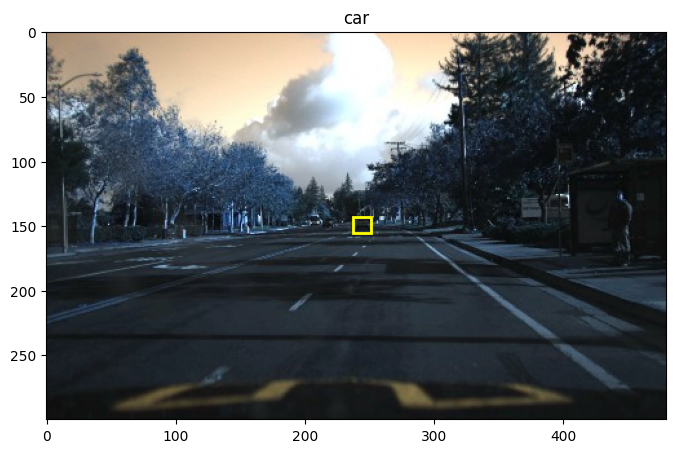

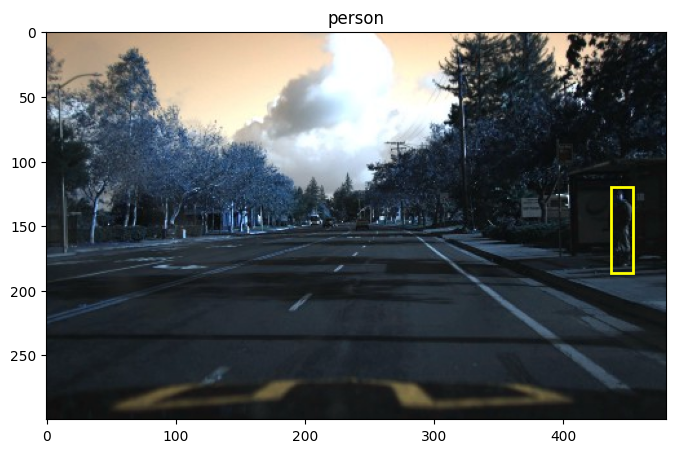

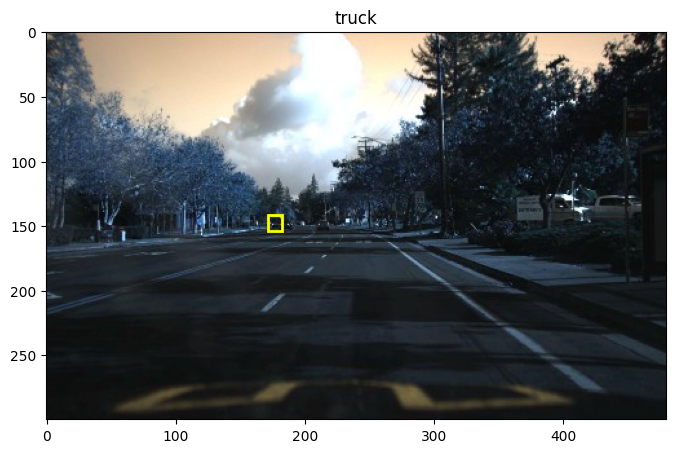

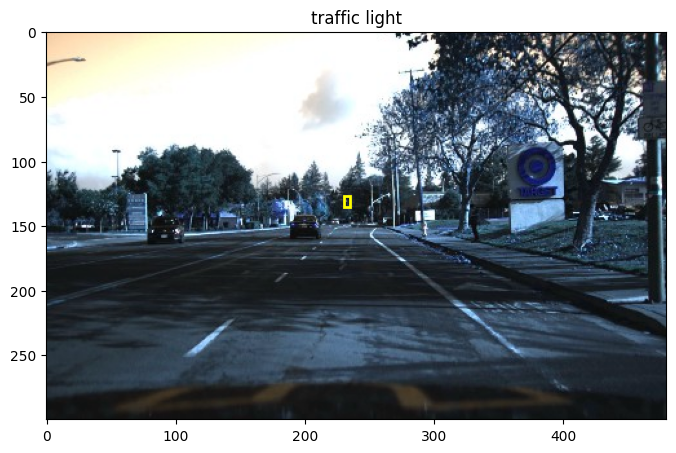

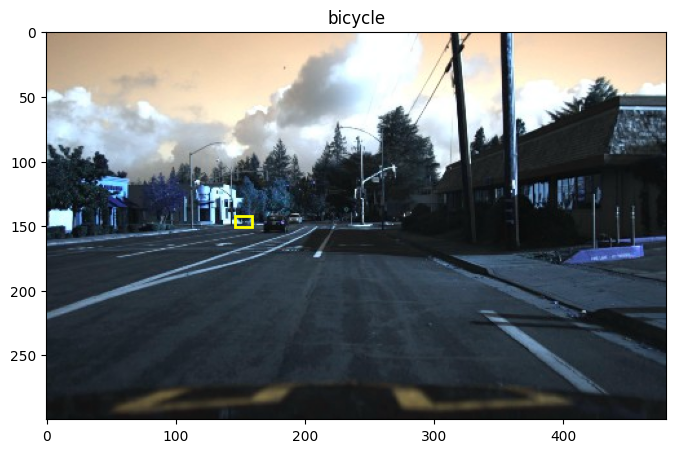

In [ ]:
for i in classes:

    xmin, xmax, ymin, ymax = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]

    plt.figure(figsize=(8, 10))
    plt.title( labels[i])
    plt.imshow(images[i])
    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color='yellow', fill=False, linewidth=2))

    plt.show()

### Model

In [ ]:
from ultralytics import YOLO
import PIL
from PIL import Image
from IPython.display import display
import os
import pathlib

In [ ]:
model = YOLO("yolov8m.pt")

In [ ]:
results=model.predict(source="/content/images/1478019956680248165.jpg",
              save=True, conf=0.2,iou=0.5)


image 1/1 /content/images/1478019956680248165.jpg: 416x640 1 car, 1 truck, 62.1ms
Speed: 13.3ms preprocess, 62.1ms inference, 460.0ms postprocess per image at shape (1, 3, 416, 640)
Results saved to runs/detect/predict


In [ ]:
result = results[0]
box = result.boxes[0]

In [ ]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    probs = result.probs  # Class probabilities for classification outputs

In [ ]:
cords = box.xyxy[0].tolist()
class_id = box.cls[0].item()
conf = box.conf[0].item()
print("Object type:", class_id)
print("Coordinates:", cords)
print("Probability:", conf)

Object type: 2.0
Coordinates: [124.69143676757812, 142.68826293945312, 148.7809295654297, 162.10049438476562]
Probability: 0.7161705493927002


In [ ]:
for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)
    print("Object type:", class_id)
    print("Coordinates:", cords)
    print("Probability:", conf)
    print("---")

Object type: car
Coordinates: [125, 143, 149, 162]
Probability: 0.72
---
Object type: truck
Coordinates: [141, 139, 157, 154]
Probability: 0.31
---


In [ ]:
results1 = model.predict(source="/content/images/1478020211690815798.jpg",
              save=True, conf=0.2,iou=0.5)

Results = results1[0]


image 1/1 /content/images/1478020211690815798.jpg: 416x640 4 cars, 3 traffic lights, 27.1ms
Speed: 7.7ms preprocess, 27.1ms inference, 4.9ms postprocess per image at shape (1, 3, 416, 640)
Results saved to runs/detect/predict


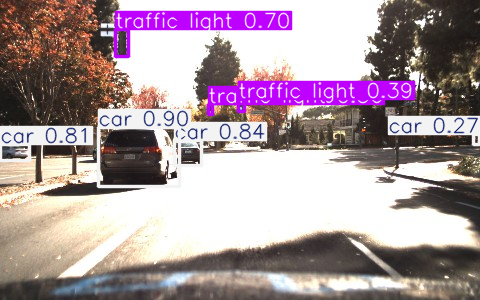

In [ ]:
# Plotting results
plot = results1[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

Tutorial on training YOLOv8 on custom dataset:

https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb

**Solar panels segmentation using YOLOv11**

YOLO (You Only Look Once) introduced segmentation capabilities starting from YOLOv8.

<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/Approach2 (1).png" alt="Image" />
</center>

## Image Segmentation

**What is Image Segmentation?**

- However, suppose you want to know the shape of that object, which pixel belongs to which object, etc. In this case, you need to assign a class to each pixel of the image—this task is known as segmentation.

- A segmentation model returns much more detailed information about the image. Image segmentation has many applications in medical imaging, self-driving cars and satellite imaging, just to name a few.

**Image segmentation** is essentially segmenting an image into fragments and assigning a label to each of those.

This occurs on a **pixel level** to define the precise outline of an object within its frame and class.

Those outlines — otherwise known as the output — are highlighted with either one or more colors, depending on the type of segmentation.

### How Does Image Segmentation Work?

We can divide or partition the image into various parts called segments. It’s not a great idea to process the entire image at the same time, as there will be regions in the image that do not contain any information. By dividing the image into segments, we can use the important segments to process the image.

An image is a collection or set of different pixels. We group the pixels that have similar attributes using image segmentation.

**Object detection** builds a bounding box corresponding to each class in the image. But it tells us **nothing about the object’s shape**—we only get the set of bounding box coordinates. We want more information—this is too vague for our purposes.

The **image segmentation algorithm** creates a **pixel-wise mask for each object in the image**. This technique gives us a far more granular understanding of the object(s) in the image.




<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/object%20detection_image%20segmentation.jpg" alt="Image" />
</center>

### What Is Image Segmentation Used For?
Cancer has long been a deadly illness. Even in today’s age of technological advancements, cancer can be fatal if we don’t identify it at an early stage. Detecting cancerous cells as quickly as possible can save millions of lives.

The **shape of the cancerous cells plays a vital role in determining the severity of the cancer**. You might have put the pieces together, but object detection will not be very useful here. We will only generate bounding boxes, which will not help us identify the shape of the cells.

Image Segmentation techniques make a MASSIVE impact here.

Source: https://pyimagesearch.com/2022/06/29/semantic-vs-instance-vs-panoptic-segmentation/


Image segmentation is a computer vision and image processing technique that involves grouping or labeling similar regions or segments in an image on a pixel level. A class label or a mask represents each segment of pixels.

In image segmentation, an image has two main components: **things** and **stuff**. **Things** correspond to **countable** objects in an image (e.g., people, flowers, birds, animals, etc.). In comparison, **stuff** represents **amorphous regions**(or repeating patterns) of similar material, which is **uncountable** (e.g., road, sky, and grass).

The difference between **semantic** vs. **instance** vs. **panoptic** segmentation lies in **how they process the things and stuff in the image**.

### Types of Image Segmentations

**Semantic segmentation** studies the **uncountable** stuff in an image. It analyzes each image pixel and assigns a unique class label based on the texture (category) it represents. For example, in the Figure 1, an image contains  three persons, a sea, a kit, a beach, and the sky. The three persons represent the same texture.

Semantic segmentation would assign unique class labels to each of these textures or categories. However, **semantic segmentation’s output cannot differentiate or count the three persons separately.** Commonly used semantic segmentation techniques include SegNet, U-Net, DeconvNet, and FCNs.

<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/semantic_instance_Panoptic.avif" alt="Image" />
</center>

**Instance segmentation** typically deals with tasks related to **countable things**. It can detect each object or instance of a class present in an image and assigns it **a different mask or bounding box with a unique identifier**.

The model learns to:
1.   Detect object boundaries
2.   Predict masks per instance
3. Classify each instance individually



For example, instance segmentation would identify the three persons in the previous example separately as, let’s say, person_1 and person_2. Commonly used instance segmentation techniques are Mask R-CNN, Faster R-CNN, PANet, and YOLACT.

The goal of both semantic and instance segmentation techniques is to process a scene coherently. Naturally, we want to identify both stuff and things in a scene to build more practical real-world applications. Researchers devised a solution to reconcile both stuff and things within a scene (i.e., panoptic segmentation).

**Panoptic segmentation** is the best of both worlds. It presents a unified image segmentation approach where each pixel in a scene is assigned a semantic label (due to semantic segmentation) and a unique instance identifier (due to instance segmentation).

**Panoptic segmentation assigns each pixel only one pair of a semantic label and an instance identifier.** However, objects can have overlapping pixels. In this case, panoptic segmentation resolves the discrepancy by favoring the object instance, as the priority is to identify each thing rather than stuff.

### U-Net Architecture

U-Net was introduced in the paper, U-Net: Convolutional Networks for Biomedical Image Segmentation. The model architecture is fairly simple: an encoder (for downsampling) and a decoder (for upsampling) with skip connections. As the Figure shows, it shapes like the letter U hence the name U-Net.


<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/UNet.png" alt="Image" />
</center>

 source: http://medium.com/data-science/u-nets-with-resnet-encoders-and-cross-connections-d8ba94125a2c

The gray arrows indicate the skip connections that concatenate the encoder feature map with the decoder, which helps the backward flow of gradients for improved training.


Now that we have a basic understanding of semantic segmentation and the U-Net architecture, let’s implement a U-Net with TensorFlow 2 / Keras.

In [ ]:
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras import backend as keras

import os
import glob
from sklearn.model_selection import train_test_split
from PIL import Image
from keras import backend as K


In [ ]:
def unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
#Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    #s = Lambda(lambda x: x / 255)(inputs)   #No need for this if we normalize our inputs beforehand
    s = inputs

    #Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    #Expansive path
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])


    return model

### Segmentation of dermoscopic images
The increasing incidence of melanoma has recently promoted the development of computer-aided diagnosis systems for the classification of dermoscopic images. The PH² dataset has been developed for research and benchmarking purposes, in order to facilitate comparative studies on both segmentation and classification algorithms of dermoscopic images. PH² is a dermoscopic image database acquired at the Dermatology Service of Hospital Pedro Hispano, Matosinhos, Portugal.

[source](https://www.fc.up.pt/addi/ph2%20database.html)

The PH² Dataset is a publicly available dataset specifically designed for skin lesion analysis, particularly for **melanoma detection** research. It contains high-quality dermoscopic images along with expert-annotated ground truth.

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import os
import zipfile

# Create Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json to the right location
!mv kaggle.json /root/.kaggle/

# Set proper permissions
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lakshyak/p2hdata

In [ ]:
with zipfile.ZipFile("p2hdata.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/PH2")

In [ ]:
root="/content/PH2/PH2Dataset/PH2 Dataset images"
size=128


In [ ]:
print(root)

In [ ]:
def reading_images(root_path, files, type_im):
    images=[]
    for file in files:
        with h5py.File(root_path + file, 'r') as img_file:
            img_for_plot = img_file[type_im][()]
            images.append(img_for_plot)
    return images

import tensorflow as tf

def jaccard_distance(y_true, y_pred, smooth=100):
    intersection = tf.reduce_sum(tf.abs(y_true * y_pred), axis=-1)
    sum_ = tf.reduce_sum(tf.square(y_true), axis=-1) + tf.reduce_sum(tf.square(y_pred), axis=-1)
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return 1 - jac  # Return the distance

In [ ]:
import numpy as np
import glob
imgs_path_list = sorted(filter(os.path.isfile,glob.glob(root+'/**/'+"**Dermoscopic_Image/"+'*bmp')))
masks_path_list = sorted(filter(os.path.isfile,glob.glob(root+'/**/'+"**lesion/"+'*bmp')))

masks=[]
imgs=[]
for idx in range(len(imgs_path_list)):
    img=np.array(Image.open(imgs_path_list[idx]).resize((size,size)), dtype=np.float32)/255
    mask=np.array(Image.open(masks_path_list[idx]).resize((size,size)), dtype=np.float32)
    #print(img.shape)
    imgs.append(img)
    masks.append(mask)
masks_arr=np.array(masks)
imgs_arr=np.array(imgs)
imgs_arr.shape

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(imgs_arr, masks_arr, test_size = 0.25, random_state = 101)

In [ ]:
import matplotlib.pyplot as plt

def display_images_and_masks(X_train, y_train):
    """
    Display 5 random images from X_train with their corresponding segmentation masks from y_train.

    Parameters:
    - X_train: numpy array of images.
    - y_train: numpy array of segmentation masks.
    """
    # Ensure there are at least 5 images
    assert len(X_train) >= 5, "X_train must contain at least 5 images."
    assert len(y_train) >= 5, "y_train must contain at least 5 masks."

    # Randomly select 5 unique indices
    indices = np.random.choice(len(X_train), 5, replace=False)

    fig, axes = plt.subplots(5, 2, figsize=(10, 20))

    for i, index in enumerate(indices):
        ax = axes[i, 0]
        ax.imshow(X_train[index], cmap='gray')
        ax.set_title(f"Image {index}")
        ax.axis('off')

        ax = axes[i, 1]
        ax.imshow(y_train[index], cmap='gray')
        ax.set_title(f"Mask {index}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
display_images_and_masks(X_train, y_train)

In [ ]:
model=unet_model(size, size, 3)

In [ ]:
model.summary()

In [ ]:
model.compile(optimizer= Adam(learning_rate = 0.001),
              metrics=['accuracy'],
              loss=  jaccard_distance)


In [ ]:
model_history=model.fit(X_train, y_train,
                       batch_size=32,
                       epochs=50,
                        verbose=1,
                       validation_data=(X_test, y_test),
                        shuffle=True
                       )


In [ ]:
import pandas as pd

In [ ]:
#%%
# Save the training history to a CSV file
history_df = pd.DataFrame(model_history.history)
history_df.to_csv(f"training_history.csv", index=False)
#%%
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(model_history.history['accuracy'], label='Train')
plt.plot(model_history.history['val_accuracy'], label='Validation')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(model_history.history['loss'], label='Train')
plt.plot(model_history.history['val_loss'], label='Validation')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.tight_layout()



In [ ]:
predictions=model.predict(X_test)>0.5

In [ ]:
def display_images_masks_predictions(X_train, y_train, predictions):
    """
    Display 5 random images from X_train with their corresponding segmentation masks from y_train
    and predicted masks from predictions.

    Parameters:
    - X_train: numpy array of images.
    - y_train: numpy array of true segmentation masks.
    - predictions: numpy array of predicted segmentation masks.
    """
    # Ensure there are at least 5 images and consistency in dataset size
    assert len(X_train) >= 5, "X_train must contain at least 5 images."
    assert len(y_train) >= 5, "y_train must contain at least 5 masks."
    assert len(predictions) >= 5, "predictions must contain at least 5 masks."
    assert len(X_train) == len(y_train) == len(predictions), "X_train, y_train, and predictions must have the same length."

    # Randomly select 5 unique indices
    indices = np.random.choice(len(X_train), 5, replace=False)

    fig, axes = plt.subplots(5, 3, figsize=(15, 20))  # Adjusted for 3 columns

    for i, index in enumerate(indices):
        # Display the original image
        ax = axes[i, 0]
        ax.imshow(X_train[index], cmap='gray')
        ax.set_title(f"Image {index}")
        ax.axis('off')

        # Display the true mask
        ax = axes[i, 1]
        ax.imshow(y_train[index], cmap='gray')
        ax.set_title(f"True Mask {index}")
        ax.axis('off')

        # Display the predicted mask
        ax = axes[i, 2]
        ax.imshow(predictions[index], cmap='gray')
        ax.set_title(f"Predicted Mask {index}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
display_images_masks_predictions(X_test, y_test, predictions)

In [ ]:
predictions.shape, y_test.shape

<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/IoU.jpg" alt="Image" />
</center>

In [ ]:
def mean_iou(y_test, predictions):
    """
    Compute the mean Intersection over Union (IoU) between two arrays of segmentation masks.

    Parameters:
    - y_test: numpy array of true segmentation masks.
    - predictions: numpy array of predicted segmentation masks.

    Returns:
    - mean_iou: The mean IoU score across all samples.
    """
    # Ensure predictions and ground truth have the same shape
    assert y_test.shape == predictions.shape, "Shape mismatch between ground truth and predictions"

    # Initialize list to store IoU scores
    iou_scores = []

    for true_mask, pred_mask in zip(y_test, predictions):
        # Intersection and union
        intersection = np.logical_and(true_mask, pred_mask)
        union = np.logical_or(true_mask, pred_mask)

        # Avoid division by zero
        iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) != 0 else 0
        iou_scores.append(iou_score)

    # Calculate mean IoU
    mean_iou = np.mean(iou_scores)
    return mean_iou

In [ ]:
print(f'The mean Intersection over Union is: {mean_iou(np.expand_dims(y_test, axis=-1), predictions)}')

In [ ]:
from tensorflow.keras.models import save_model

# Save the model in the SavedModel format
model.save('my_model.keras')



In [ ]:
from tensorflow.keras.utils import get_custom_objects

# Define the jaccard_distance function
def jaccard_distance(y_true, y_pred):
    # Your implementation of the Jaccard distance
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return 1 - intersection / union

# Register the custom function with Keras
get_custom_objects()['jaccard_distance'] = jaccard_distance

In [ ]:
from tensorflow.keras.models import load_model

# Load the model
new_model = load_model('my_model.keras', custom_objects={'jaccard_distance': jaccard_distance})

In [ ]:
new_model.summary()

### Carotid Ultrasound Images Segmetation using Unet


In [ ]:
import numpy as np
import pandas as pd
import os


In [ ]:
from google.colab import files
files.upload()

In [ ]:
import os
import zipfile

# Create Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json to the right location
!mv kaggle.json /root/.kaggle/

# Set proper permissions
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d orvile/carotid-ultrasound-images

In [ ]:
with zipfile.ZipFile("carotid-ultrasound-images.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/carotid-ultrasound-images ")

In [ ]:
base_path = "/content/carotid-ultrasound-images /Common Carotid Artery Ultrasound Images/Common Carotid Artery Ultrasound Images/"
image_dir = base_path + "US images/"
mask_dir = base_path + "Expert mask images/"
import os
print("Sample ultrasound images:", os.listdir(image_dir)[:5])
print("Sample masks:", os.listdir(mask_dir)[:5])

print(f"Total images: {len(os.listdir(image_dir))}")
print(f"Total masks: {len(os.listdir(mask_dir))}")

In [ ]:
import pandas as pd
image_files = sorted([os.path.join(image_dir, f) for f in
os.listdir(image_dir)])
mask_files = sorted([os.path.join(mask_dir, f) for f in
os.listdir(mask_dir)])
df = pd.DataFrame({"image_path": image_files, "mask_path": mask_files})
print(df.shape)
df.columns


In [ ]:
import matplotlib.pyplot as plt
import random
import cv2
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))
assert all(im.split('.')[0] == mk.split('.')[0] for im, mk in
zip(image_files, mask_files)), "Mismatched files!"
fig, axes = plt.subplots(5, 2, figsize=(10, 25))
for idx in range(5):
  random_index = random.randint(0, len(image_files)-1)
  img_path = os.path.join(image_dir, image_files[random_index])
  mask_path = os.path.join(mask_dir, mask_files[random_index])
  img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
  mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
  axes[idx, 0].imshow(img)
  axes[idx, 0].set_title(f"Ultrasound Image\n{image_files[random_index]}")
  axes[idx, 0].axis('off')
  axes[idx, 1].imshow(mask, cmap='gray')
  axes[idx, 1].set_title(f"Expert Mask\n{mask_files[random_index]}")
  axes[idx, 1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
missing_masks = [f for f in image_files if f not in mask_files]
if missing_masks:
  raise ValueError(f"Missing masks for {len(missing_masks)} images, including: {missing_masks[:3]}")
file_pairs = [
(os.path.join(image_dir, f), os.path.join(mask_dir, f))
for f in image_files
]
df = pd.DataFrame(file_pairs, columns=['image_path', 'mask_path'])
df

In [ ]:
def extract_subject_id(filename):
  '''Extracts subject ID from filenames like:
  - 202201121748100022VAS_slice_1069.png
  - 202202071308300020EM VASCULAR_slice_695.png
  '''
  parts = filename.split('_')

  if len(parts) < 3:
    raise ValueError(f"Unexpected filename format: {filename}")
  first_part = parts[0]
  timestamp_length = 18
  if len(first_part) < timestamp_length:
    raise ValueError(f"Unexpected first part length: {first_part}")
  identifier = first_part[timestamp_length:]
  subject_id = identifier.split()[0].strip()
  return subject_id
df['subject_id'] = df['image_path'].apply(lambda x:
extract_subject_id(os.path.basename(x)))
print("Unique Subject IDs:", df['subject_id'].unique())


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
def unet(input_size=(256, 256, 3)):
  inputs = Input(input_size)
  c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
  c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
  p1 = MaxPooling2D((2, 2))(c1)
  c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
  c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
  p2 = MaxPooling2D((2, 2))(c2)
  c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
  c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
  p3 = MaxPooling2D((2, 2))(c3)
  c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3)

  c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(c4)
  p4 = MaxPooling2D((2, 2))(c4)
  c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(p4)
  c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(c5)
  u6 = UpSampling2D((2, 2))(c5)
  u6 = concatenate([u6, c4])
  c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
  c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(c6)
  u7 = UpSampling2D((2, 2))(c6)
  u7 = concatenate([u7, c3])
  c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
  c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(c7)
  u8 = UpSampling2D((2, 2))(c7)
  u8 = concatenate([u8, c2])
  c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(u8)
  c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(c8)
  u9 = UpSampling2D((2, 2))(c8)
  u9 = concatenate([u9, c1])
  c9 = Conv2D(16, (3, 3), activation='relu', padding='same')(u9)
  c9 = Conv2D(16, (3, 3), activation='relu', padding='same')(c9)
  outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
  model = Model(inputs=[inputs], outputs=[outputs])
  return model

In [ ]:
def load_data(df, image_size=(256, 256)):
  images = []
  masks = []
  for image_path, mask_path in zip(df['image_path'], df['mask_path']):
    img = load_img(image_path, target_size=image_size)
    img = img_to_array(img) / 255.0
    images.append(img)
    mask = load_img(mask_path, target_size=image_size,color_mode='grayscale')
    mask = img_to_array(mask) / 255.0
    masks.append(mask)
  return np.array(images), np.array(masks)

In [ ]:
images, masks = load_data(df)
masks = np.expand_dims(masks, axis=-1)

X_train, X_test, y_train, y_test = train_test_split(images, masks,test_size=0.2, random_state=42)
model = unet()
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
early_stopping = EarlyStopping(patience=10, verbose=1,restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.1, patience=5, verbose=1)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),epochs=5, batch_size=32, callbacks=[early_stopping, reduce_lr])

In [ ]:
def plot_history(history):
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'])
  if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
  else:
    plt.title('Model accuracy')

    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train'], loc='upper left')
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'])
  if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
  else:
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train'], loc='upper left')
    plt.tight_layout()
  plt.show()
plot_history(history)

In [ ]:
def calculate_iou(y_true, y_pred):
  intersection = np.logical_and(y_true, y_pred).sum()
  union = np.logical_or(y_true, y_pred).sum()
  if union == 0:
    return 0.0
  return intersection / union
def calculate_dice(y_true, y_pred):
  intersection = np.logical_and(y_true, y_pred).sum()
  total = y_true.sum() + y_pred.sum()
  if total == 0:
    return 0.0
  return 2 * intersection / total

y_pred_binary = (model.predict(X_test) > 0.5).astype(bool)
y_test_binary = y_test.astype(bool)
iou = calculate_iou(y_test_binary.squeeze(), y_pred_binary.squeeze())
dice = calculate_dice(y_test_binary.squeeze(), y_pred_binary.squeeze())
print(f"IoU: {iou}")
print(f"Dice: {dice}")

<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/IoU.jpg" alt="Image" />
</center>

<center>
  <img src="https://raw.githubusercontent.com/MazenMTULab/ML_COURSE_RESOURCES/main/Figs/Dice.avif" alt="Image" />
</center>